# YOLO-BLBE: Blueberry Fruit Maturity Detection with I-MSRCR — Minimal Colab Reproduction

**Paper:** *YOLO-BLBE: A Novel Model for Identifying Blueberry Fruits with Different Maturities Using the I-MSRCR Method*, Agronomy 14(4):658 (2024). DOI: [10.3390/agronomy14040658](https://doi.org/10.3390/agronomy14040658)

**Author code (pinned):** [`abysswatcher-hqy/YOLO-BLBE`](https://github.com/abysswatcher-hqy/YOLO-BLBE) @ commit `bd2e806828d81aad783412384bf9ff2998483cd2` (only commit on `main`, pushed 2023-10-14; the paper-linked investigation cites this repository's tree `796fb8e5...`).

**Scope (executed):** one repository sample field image (`data/sample/93.jpg`), the author's
MSRCR color enhancement (`retinex.py` + repo `config.json`), and the author's `detect.py`
inference (`run()`, imgsz 640, conf ≥ 0.5) using the committed trained weights
`runs/exp0-ghost+fibn-epoch200/weights/best.pt` (13,360,111 bytes, GhostNet+BiFPN experiment).
This demonstrates the paper's pipeline on a **single example** — it does **not** reproduce the
paper's dataset-level accuracy (99.58% / 96.77% / 98.07%) or benchmark tables.

**重要な注意 (AI-assisted glue):** The notebook executes the **authors' own pinned code and
weights**; the only AI-generated parts are the Colab glue cells (pinned partial clone,
a `torch.load` compatibility patch, and result tables). The authors did not provide this
Colab notebook itself. The executed example and checks were validated, but untested behavior
is not guaranteed. **本ノートブックは著者の pinned コードと重みをそのまま実行します。Colab 接続用の数セルのみ AI が追加しており、著者提供の Colab 実装ではありません。**

**Known caveats (do not skip):**
- The repository has **no LICENSE** and no public statement ties it to the paper's authors;
  identity rests on the unique model name, the 3-class blueberry maturity task, and the
  GhostNet/BiFPN experiment layout (investigation finding, 2026-10-08).
- The committed `best.pt` (13,360,111 B) differs in size from the paper's reported final
  12.75 MB model; identity with the published final configuration is **unconfirmed**.
- The repo implements classic MSRCR (`retinex.py`); the paper's exact **I-MSRCR** adjustment
  of color-restoration proportions is not labeled in code. We use the repo's own
  `config.json` parameters as-is.
- Full paper text was inaccessible (MDPI 403; no OpenAlex copy), so method details beyond
  the abstract/code could not be cross-checked.
- The fork **omits upstream YOLOv5's `export.py`** although `models/common.py` imports it;
  a minimal compatibility shim (section 2b) restores that missing import. Found during a
  2026-10-10 CPU validation run (archived as attempt 1).

## Runtime selection / ランタイム選択

**Runtime → Change runtime type → select CPU (default) or T4 GPU.** The method runs on CPU
in seconds; a T4 GPU is optional and mainly lets you compare inference speed with the paper's
reported 0.009 s average detection speed (measured on the authors' hardware). The notebook
auto-detects the allocated device — do not change any code between the two paths.

**実行時間:** 環境準備とダウンロードは数分、推論は 1 枚あたり CPU で数秒です。GPU (T4) は任意で、速度比較にのみ有用です。

In [ ]:
# Environment check: verify all third-party imports of the author's detect path,
# report Python/torch/CUDA, and pick the device for this allocated runtime.
import sys, platform

print("Python:", sys.version.split()[0], "|", platform.machine())

import torch, torchvision, cv2, numpy, pandas, yaml, PIL, requests, matplotlib, seaborn, tqdm

print("torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| numpy", numpy.__version__, "| opencv", cv2.__version__)
print("CUDA available:", torch.cuda.is_available(),
      "| device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print("This run will use device:", DEVICE)

EXPECTED = ["torch", "torchvision", "cv2", "numpy", "pandas", "yaml",
            "PIL", "requests", "matplotlib", "seaborn", "tqdm"]
missing = [m for m in EXPECTED if m not in sys.modules]
assert not missing, f"Missing modules: {missing} — install them in a cell above before continuing."
print("All author-code dependencies importable.")

Python: 3.13.16 | x86_64


torch 2.11.0+cpu | torchvision 0.26.0+cpu | numpy 2.1.3 | opencv 5.0.0
CUDA available: False | device count: 0
This run will use device: cpu
All author-code dependencies importable.


## 1. Pinned author code acquisition / pin した著者コードの取得

We clone the author repository **inside Colab only**, with a *partial, sparse, pinned* clone:
`--filter=blob:none --no-checkout --depth 1` fetches no file bytes until checkout, and a
sparse-checkout pattern selects only the code directories plus the single sample image and
the single weight file. The checkout is verified against the pinned commit
`bd2e806828d81aad783412384bf9ff2998483cd2` (asserted via `git rev-parse HEAD`), and the two
large artifacts are verified against their pinned git blob SHA-1s from the repository tree.

**Colab 内でのみ** blob 非取得の部分クローンを行い、sparse-checkout で必要ファイルだけを展開します。コミットと blob ハッシュを検証します。

In [ ]:
import os, subprocess

REPO_URL = "https://github.com/abysswatcher-hqy/YOLO-BLBE"
PINNED_COMMIT = "bd2e806828d81aad783412384bf9ff2998483cd2"
REPO_DIR = "/content/YOLO-BLBE"

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", "--depth", "1",
                    REPO_URL, REPO_DIR], check=True)

# Select only what the demonstration needs: code dirs + one sample + one weight file.
subprocess.run(["git", "-C", REPO_DIR, "sparse-checkout", "init", "--no-cone"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "sparse-checkout", "set",
                "*.py", "models", "utils", "config.json", "README.md",
                "data/bluestrawberry.yaml", "data/sample/93.jpg",
                "runs/exp0-ghost+fibn-epoch200/weights/best.pt"], check=True)
subprocess.run(["git", "-c", "advice.detachedHead=false", "-C", REPO_DIR, "checkout",
                PINNED_COMMIT], check=True)

head = subprocess.run(["git", "-C", REPO_DIR, "rev-parse", "HEAD"],
                      capture_output=True, text=True, check=True).stdout.strip()
assert head == PINNED_COMMIT, f"Checkout mismatch: {head} != {PINNED_COMMIT}"
print("Checked out pinned commit:", head)
for rel in ["detect.py", "retinex.py", "config.json", "models/common.py",
            "data/sample/93.jpg", "runs/exp0-ghost+fibn-epoch200/weights/best.pt"]:
    p = os.path.join(REPO_DIR, rel)
    assert os.path.isfile(p), f"missing after sparse checkout: {rel}"
    print(f"  ok {rel} ({os.path.getsize(p):,} B)")

Checked out pinned commit: bd2e806828d81aad783412384bf9ff2998483cd2
  ok detect.py (13,572 B)
  ok retinex.py (3,995 B)
  ok config.json (124 B)
  ok models/common.py (43,829 B)
  ok data/sample/93.jpg (1,249,307 B)
  ok runs/exp0-ghost+fibn-epoch200/weights/best.pt (13,360,111 B)


## 2. Compatibility patch for modern PyTorch / 新しい PyTorch への互換パッチ

The 2023-era code loads its checkpoint with a bare `torch.load(...)` (models/experimental.py:96).
PyTorch ≥ 2.6 defaults `weights_only=True`, which rejects full-model pickles. We set the
default to `weights_only=False` **for this trusted, pinned author code load only** (any
explicit caller argument is preserved). We also make sure `pkg_resources` (used by
utils/general.py) is importable.

2022–2023 年時代のコードは `torch.load` の既定動作を前提としているため、pin された著者コードの読み込みに限り `weights_only=False` を既定化します。

In [ ]:
import subprocess

try:
    import pkg_resources  # noqa: F401  (used by utils/general.py)
    print("pkg_resources importable")
except ModuleNotFoundError:
    print("installing setuptools for pkg_resources ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "setuptools"], check=True)
    import pkg_resources  # noqa: F401
    print("pkg_resources importable (installed)")

import torch

_orig_torch_load = torch.load

def _torch_load_compat(*args, **kwargs):
    kwargs.setdefault("weights_only", False)  # author code never passes weights_only
    return _orig_torch_load(*args, **kwargs)

torch.load = _torch_load_compat
print(f"torch.load patched: default weights_only=False (torch {torch.__version__})")

pkg_resources importable
torch.load patched: default weights_only=False (torch 2.11.0+cpu)


/tmp/ipykernel_2084/2210550185.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: F401  (used by utils/general.py)


## 2b. Restoring a module the authors omitted / 著者リポジトリに欠けているモジュールの補完

The pinned fork's `DetectMultiBackend.model_type()` does `from export import export_formats`
(models/common.py:483), but the repository **never committed `export.py`** (verified in the
pinned tree), so any checkpoint load fails with `ModuleNotFoundError: No module named 'export'`.
We register a minimal virtual module that reproduces the upstream YOLOv5 v6.2
`export_formats()` table verbatim (11 rows — the era this fork derives from; only its
`Suffix` column is consulted, to classify the `.pt` weights). **No author file is modified
or overwritten.** **AI-generated compatibility shim** following ultralytics/yolov5 v6.2
`export.py`. The same cell pre-fetches the drawing font (`check_font`) because torch ≥ 2.x
raises a non-`URLError` exception on download failure that the 2023 code does not catch; on
failure it substitutes matplotlib's DejaVuSans for label text rendering only.

著者リポジトリには上流 YOLOv5 の `export.py` が含まれていません。上流と同じ形式表を返す最小限の仮想モジュールを登録します（著者のファイルは変更しません）。

In [ ]:
import sys, types

import pandas as pd

sys.path.insert(0, REPO_DIR)  # import author modules from the pinned clone

export_mod = types.ModuleType("export")

def export_formats():
    # Upstream YOLOv5 v6.2 export_formats() table (ultralytics/yolov5 export.py @ v6.2);
    # DetectMultiBackend.model_type() reads the Suffix column (expects 11 rows + '.xml').
    x = [
        ["PyTorch", "-", ".pt", True, True],
        ["TorchScript", "torchscript", ".torchscript", True, True],
        ["ONNX", "onnx", ".onnx", True, True],
        ["OpenVINO", "openvino", "_openvino_model", True, False],
        ["TensorRT", "engine", ".engine", False, True],
        ["CoreML", "coreml", ".mlmodel", True, False],
        ["TensorFlow SavedModel", "saved_model", "_saved_model", True, True],
        ["TensorFlow GraphDef", "pb", ".pb", True, True],
        ["TensorFlow Lite", "tflite", ".tflite", True, False],
        ["TensorFlow Edge TPU", "edgetpu", "_edgetpu.tflite", False, False],
        ["TensorFlow.js", "tfjs", "_web_model", False, False],
    ]
    return pd.DataFrame(x, columns=["Format", "Argument", "Suffix", "CPU", "GPU"])

export_mod.export_formats = export_formats
sys.modules["export"] = export_mod
print("Virtual 'export' module registered (upstream YOLOv5 v6.2 export_formats table).")

# Pre-fetch the drawing font the author Annotator uses (utils/general.py check_font);
# torch>=2.x raises RuntimeError (not URLError) on download failure, which the author
# code does not catch, so guard it here.
from pathlib import Path

from utils.general import CONFIG_DIR, check_font

try:
    check_font("Arial.ttf")
    print("Arial.ttf available:", Path(CONFIG_DIR, "Arial.ttf").exists())
except Exception as e:
    import shutil

    import matplotlib
    src = Path(matplotlib.get_data_path()) / "fonts/ttf/DejaVuSans.ttf"
    shutil.copy(src, Path(CONFIG_DIR, "Arial.ttf"))
    print(f"Arial.ttf download failed ({type(e).__name__}); substituted matplotlib's "
          "DejaVuSans.ttf for label-text rendering only (no effect on detections).")

INFO:yolov5:Downloading https://ultralytics.com/assets/Arial.ttf to /root/.config/Ultralytics/Arial.ttf...


Virtual 'export' module registered (upstream YOLOv5 v6.2 export_formats table).


Arial.ttf available: True


## 3. Artifact verification / 入力と重みの検証

Verify the downloaded bytes **before** scientific use: expected sizes, JPEG and ZIP file
signatures (a `.pt` is a zip container; reject LFS-pointer text), pinned git blob SHA-1s from
`git ls-tree`, and SHA-256 digests for the run record.

サイズ・ファイルシグネチャ・pin された blob SHA-1・SHA-256 を検証します。

In [ ]:
import hashlib
from pathlib import Path

IMG = Path(REPO_DIR) / "data/sample/93.jpg"
WEIGHTS = Path(REPO_DIR) / "runs/exp0-ghost+fibn-epoch200/weights/best.pt"
DATA_YAML = Path(REPO_DIR) / "data/bluestrawberry.yaml"
CONFIG = Path(REPO_DIR) / "config.json"

def blob_sha(path_rel):
    out = subprocess.run(["git", "-C", REPO_DIR, "ls-tree", "HEAD", path_rel],
                         capture_output=True, text=True, check=True).stdout.split()
    return out[2]

# Expected values from the pinned tree 796fb8e5... (verified via GitHub API 2026-10-09).
EXPECT = {str(IMG): (1249307, "62459304be7e59d5aabb859c57abf89fb190d388"),
          str(WEIGHTS): (13360111, "9ba3904167b3a2c57e934ceef0646269a89ea265")}
for path, (size, bsha) in EXPECT.items():
    p = Path(path)
    assert p.stat().st_size == size, f"{p.name}: size {p.stat().st_size} != {size}"
    assert blob_sha(str(p.relative_to(REPO_DIR))) == bsha, f"{p.name}: blob sha mismatch"
    digest = hashlib.sha256(p.read_bytes()).hexdigest()
    print(f"{p.name}: {size:,} B | blob {bsha[:12]}... | sha256 {digest[:16]}...")

assert IMG.read_bytes()[:2] == b"\xff\xd8", "93.jpg is not a JPEG"
head = WEIGHTS.read_bytes()[:2]
assert head == b"PK", f"best.pt is not a zip-container .pt (head={head!r})"
print("93.jpg JPEG signature ok; best.pt zip-container signature ok (not an LFS pointer).")

import yaml
data_cfg = yaml.safe_load(DATA_YAML.read_text())
CLASS_NAMES = data_cfg["names"]
print("Dataset YAML classes (data/bluestrawberry.yaml):", CLASS_NAMES, "| nc =", data_cfg["nc"])

93.jpg: 1,249,307 B | blob 62459304be7e... | sha256 a1a8770679abd9a1...
best.pt: 13,360,111 B | blob 9ba3904167b3... | sha256 ae8120df17513440...
93.jpg JPEG signature ok; best.pt zip-container signature ok (not an LFS pointer).
Dataset YAML classes (data/bluestrawberry.yaml): ['Mature fruit', 'Semimature fruit', 'Immature fruit'] | nc = 3


## 4. Input preview / 入力画像のプレビュー

`data/sample/93.jpg` is one of the ten field images the authors committed for testing.
We display it here unchanged (dimensions printed from the actual file) before any processing.
**入力画像をそのまま表示します。**

93.jpg preview (matplotlib backend: module://matplotlib_inline.backend_inline)
93.jpg decoded: 3648x2736x3 (BGR)


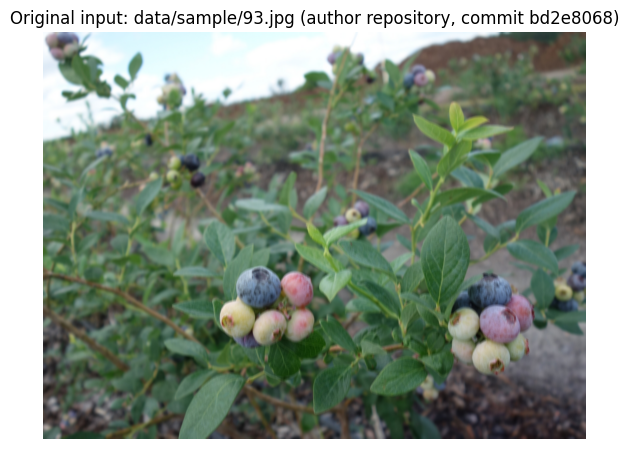

In [ ]:
import cv2
import matplotlib
import matplotlib.pyplot as plt

PREV_BACKEND = matplotlib.get_backend()  # remembered; utils/plots.py forces 'Agg' on import
print(f"93.jpg preview (matplotlib backend: {PREV_BACKEND})")

img_bgr = cv2.imread(str(IMG))  # author pipeline uses OpenCV BGR
assert img_bgr is not None, "cv2.imread failed on 93.jpg"
h, w, ch = img_bgr.shape
print(f"93.jpg decoded: {w}x{h}x{ch} (BGR)")

plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original input: data/sample/93.jpg (author repository, commit bd2e8068)")
plt.axis("off")
plt.show()

## 5. MSRCR color enhancement (paper stage 2) / MSRCR 色補強

The paper's second contribution enhances fruit/canopy color contrast before detection
("I-MSRCR"). The repo provides `retinex.py` with `MSRCR(img, sigma_list, G, b, alpha, beta,
low_clip, high_clip)` and `config.json` holding the parameters used with this code
(sigma_list [80], G 5.0, b 25.0, alpha 125.0, beta 46.0, low_clip 0.01, high_clip 0.99 per
the paper-linked asset record; printed from the actual file below). The code labels the
function plain **MSRCR** — the paper's exact "I-MSRCR" restoration proportions are not stated
in readable sources, so we apply the author parameters as-is.

著者の `retinex.py` とリポジトリの `config.json` をそのまま使い、元画像と処理後を並べて表示します。

config.json: {'sigma_list': [80], 'G': 5.0, 'b': 25.0, 'alpha': 125.0, 'beta': 46.0, 'low_clip': 0.01, 'high_clip': 0.99}


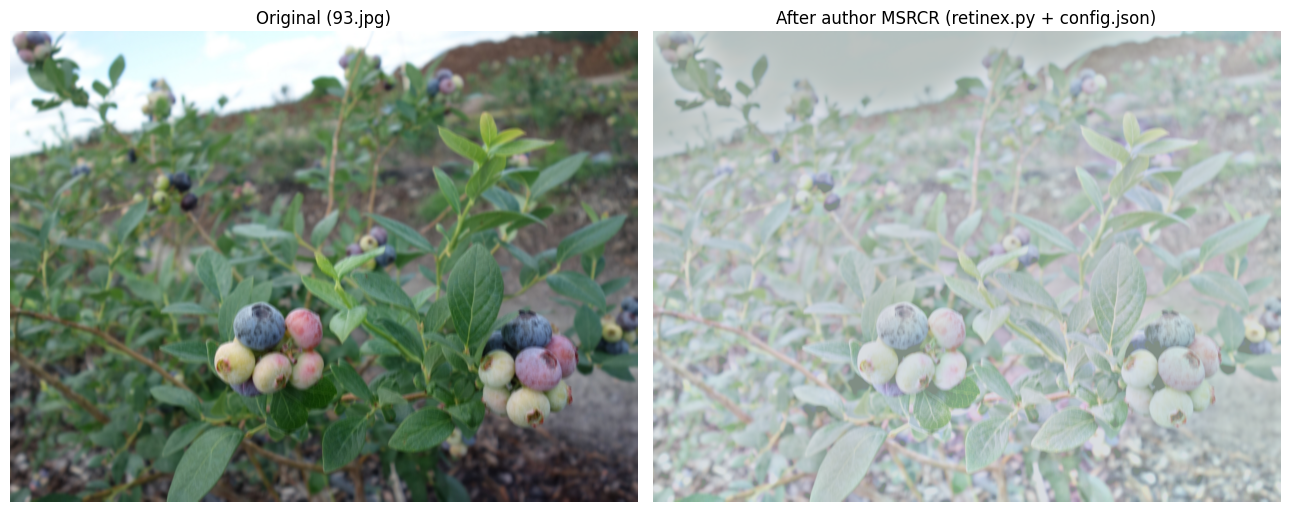

In [ ]:
import json, sys

sys.path.insert(0, REPO_DIR)  # import author modules from the pinned clone
from retinex import MSRCR  # author implementation (retinex.py @ bd2e8068)

cfg = json.loads(CONFIG.read_text())
print("config.json:", cfg)

enhanced_bgr = MSRCR(img_bgr.copy(), **cfg)  # author MSRCR with repo parameters

fig, axes = plt.subplots(1, 2, figsize=(13, 9))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original (93.jpg)")
axes[1].imshow(cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("After author MSRCR (retinex.py + config.json)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Inference on the original image (author `detect.py`) / 元画像での推論

We call the author's own inference function `detect.run()` (detect.py @ bd2e8068) with the
author CLI defaults for this repository: `imgsz 640`, `conf_thres 0.5` (the repo's modified
default), `iou_thres 0.45`, `--save-txt --save-conf`, on the pinned `best.pt`. The device is
the one allocated to this runtime (CPU or T4). The cell also undoes the module-level
`matplotlib.use('Agg')` from the author's `utils/plots.py` so later figures display inline
again. The output is the author-style annotated image with per-class model predictions; the
class names come from `data/bluestrawberry.yaml`.

著者の `detect.run()` をそのまま呼び出します（imgsz 640、conf 0.5 はリポジトリの既定値）。また、著者コードの import 時に強制される Agg バックエンドを元に戻します。検出結果（モデル予測）を描画した画像を表示します。

In [ ]:
from detect import run  # author entry point; importing detect adds the repo to sys.path

# utils/plots.py:29 calls matplotlib.use('Agg') at module level, which silently disables
# inline figure display for the rest of the session. Restore the backend captured in
# section 4 (display-only change; no effect on detections).
import matplotlib

matplotlib.use(PREV_BACKEND)
print("matplotlib backend restored to", matplotlib.get_backend())

OUT_ORIG = "/content/outputs/detect_original"
run(weights=str(WEIGHTS), source=str(IMG), data=str(DATA_YAML),
    imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000,
    device=DEVICE, save_txt=True, save_conf=True,
    project="/content/outputs", name="detect_original", exist_ok=True)

INFO:yolov5:YOLOv5 🚀 bd2e806 torch 2.11.0+cpu CPU



YOLOv5 🚀 bd2e806 torch 2.11.0+cpu CPU



INFO:yolov5:Fusing layers... 


Fusing layers... 


matplotlib backend restored to module://matplotlib_inline.backend_inline


...

image 1/1 /content/YOLO-BLBE/data/sample/93.jpg: 480x640 1 Mature fruit, 1 Semimature fruit, 4 Immature fruits, Done. (0.444s)


INFO:yolov5:Speed: 2.1ms pre-process, 443.9ms inference, 31.9ms NMS per image at shape (1, 3, 640, 640)


Speed: 2.1ms pre-process, 443.9ms inference, 31.9ms NMS per image at shape (1, 3, 640, 640)


INFO:yolov5:Results saved to /content/outputs/detect_original
1 labels saved to /content/outputs/detect_original/labels


Results saved to /content/outputs/detect_original
1 labels saved to /content/outputs/detect_original/labels


**Detected fruits on the original image** — the annotation overlay is a **model prediction**
by the pinned `best.pt` (these samples carry no reference annotations), drawn by the author's
`Annotator`. **（モデル予測のオーバーレイ表示。正解アノテーションはありません。）**

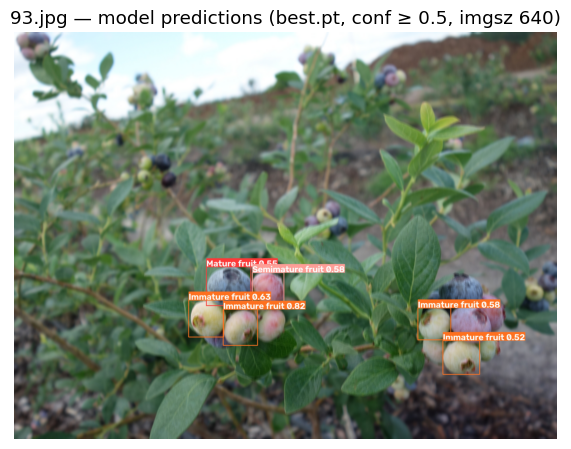

Original image: 6 detections
class
Immature fruit      4
Mature fruit        1
Semimature fruit    1


In [ ]:
import numpy as np
import pandas as pd

ann_path = "/content/outputs/detect_original/93.jpg"
ann = cv2.imread(ann_path)
assert ann is not None, f"author detect.py did not save {ann_path}"

plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
plt.title("93.jpg — model predictions (best.pt, conf ≥ 0.5, imgsz 640)")
plt.axis("off")
plt.show()

def detections_frame(labels_txt):
    cols = ["class_id", "x_center", "y_center", "width", "height", "confidence"]
    if not Path(labels_txt).exists():  # no detections above threshold
        return pd.DataFrame(columns=cols + ["class"])
    lab = np.loadtxt(labels_txt).reshape(-1, len(cols))
    df = pd.DataFrame(lab, columns=cols)
    df["class"] = df["class_id"].astype(int).map(dict(enumerate(CLASS_NAMES)))
    return df

labels_orig = "/content/outputs/detect_original/labels/93.txt"
df_orig = detections_frame(labels_orig)
print(f"Original image: {len(df_orig)} detections")
print(df_orig["class"].value_counts().rename_axis("class").to_string())

## 7. Inference on the MSRCR-enhanced image / MSRCR 処理後画像での推論

The paper trains on I-MSRCR-synthesized images and applies enhancement to inputs; here we run
the same author inference on the MSRCR-enhanced version of the same image to compare behavior.
The enhanced image is saved under `/content` and passed through the identical call.

同じ著者推論を MSRCR 処理後画像にも適用し、結果を比較します。

In [ ]:
enh_path = "/content/outputs/93_msrcr.jpg"
cv2.imwrite(enh_path, enhanced_bgr)

OUT_ENH = "/content/outputs/detect_msrcr"
run(weights=str(WEIGHTS), source=enh_path, data=str(DATA_YAML),
    imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000,
    device=DEVICE, save_txt=True, save_conf=True,
    project="/content/outputs", name="detect_msrcr", exist_ok=True)

INFO:yolov5:YOLOv5 🚀 bd2e806 torch 2.11.0+cpu CPU



YOLOv5 🚀 bd2e806 torch 2.11.0+cpu CPU



INFO:yolov5:Fusing layers... 


Fusing layers... 


INFO:yolov5:YOLOv5s summary: 239 layers, 6484472 parameters, 0 gradients


...

image 1/1 /content/outputs/93_msrcr.jpg: 480x640 1 Mature fruit, 2 Immature fruits, Done. (0.233s)


INFO:yolov5:Speed: 0.9ms pre-process, 232.6ms inference, 0.7ms NMS per image at shape (1, 3, 640, 640)


Speed: 0.9ms pre-process, 232.6ms inference, 0.7ms NMS per image at shape (1, 3, 640, 640)


INFO:yolov5:Results saved to /content/outputs/detect_msrcr
1 labels saved to /content/outputs/detect_msrcr/labels


Results saved to /content/outputs/detect_msrcr
1 labels saved to /content/outputs/detect_msrcr/labels


**Detected fruits on the MSRCR-enhanced image** — same labeling convention as above:
model predictions only. **（MSRCR 処理後画像へのモデル予測。）**

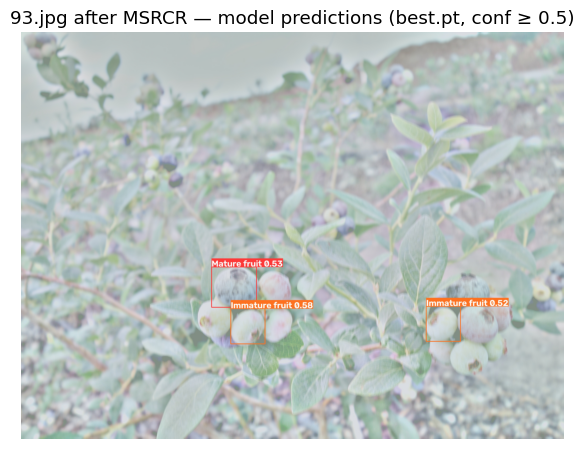

MSRCR-enhanced image: 3 detections
class
Immature fruit    2
Mature fruit      1


In [ ]:
ann_enh = cv2.imread("/content/outputs/detect_msrcr/93_msrcr.jpg")
assert ann_enh is not None, "author detect.py did not save the enhanced-result image"

plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(ann_enh, cv2.COLOR_BGR2RGB))
plt.title("93.jpg after MSRCR — model predictions (best.pt, conf ≥ 0.5)")
plt.axis("off")
plt.show()

labels_enh = "/content/outputs/detect_msrcr/labels/93_msrcr.txt"
df_enh = detections_frame(labels_enh)
print(f"MSRCR-enhanced image: {len(df_enh)} detections")
print(df_enh["class"].value_counts().rename_axis("class").to_string())

## 8. Results table and CSV export / 結果表と CSV 出力

A small comparison of the two runs (counts and mean confidence per maturity class), plus a
CSV export under `/content/outputs/`. This table is **this notebook's single-example result**,
not a reproduction of any paper table.

**この表は 1 例の実行結果であり、論文の表の再現ではありません。**

In [ ]:
def summarize(df, label):
    g = df.groupby("class")["confidence"].agg(count="count", mean_confidence="mean")
    g["run"] = label
    return g.reset_index()

summary = pd.concat([summarize(df_orig, "original"),
                     summarize(df_enh, "msrcr_enhanced")], ignore_index=True)
summary["mean_confidence"] = summary["mean_confidence"].round(4)
display(summary)

csv_path = "/content/outputs/detection_comparison.csv"
summary.to_csv(csv_path, index=False)
print("Saved:", csv_path)

,class,count,mean_confidence,run
0,Immature fruit,4,0.6365,original
1,Mature fruit,1,0.5537,original
2,Semimature fruit,1,0.5762,original
3,Immature fruit,2,0.5508,msrcr_enhanced
4,Mature fruit,1,0.5286,msrcr_enhanced


Saved: /content/outputs/detection_comparison.csv


## 9. Inference timing vs. the paper's speed claim / 推論速度の計測

The paper reports a **0.009 s average detection speed** (authors' hardware, unspecified).
Using the author's own timing method (the `time_sync()` inference interval from detect.py's
loop), we time the pinned model on the letterboxed 93.jpg three times on **this** runtime.
This contextualizes — but cannot confirm — the paper's figure; hardware differs.

著者と同じ `time_sync()` 区間の計測をこのランタイムで 3 回行い、論文値と比較します（ハードウェアは異なります）。

In [ ]:
import torch
from utils.torch_utils import time_sync  # author timing helper (utils/torch_utils.py)
from models.common import DetectMultiBackend
from utils.datasets import letterbox

device = torch.device(DEVICE)
model = DetectMultiBackend(str(WEIGHTS), device=device, data=str(DATA_YAML))
model.eval()

# Same preprocessing as detect.py's LoadImages: letterbox to 640 with auto-shape.
lb = letterbox(img_bgr, 640, stride=int(model.stride), auto=True)[0]
im = torch.from_numpy(lb).to(device).float() / 255.0
im = im.permute(2, 0, 1).unsqueeze(0)  # HWC -> 1xCHW, exactly detect.py's tensor layout

with torch.no_grad():
    model(im)  # warmup (also done by detect.run)
    times = []
    for _ in range(3):
        t0 = time_sync()
        model(im)
        times.append(time_sync() - t0)

print(f"Device: {device} ({torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'})")
print("Inference-only time per run (author time_sync interval):",
      [f"{t * 1e3:.1f} ms" for t in times])
print(f"Mean: {sum(times) / len(times) * 1e3:.1f} ms | Paper reports 0.009 s on the authors' hardware.")

INFO:yolov5:Fusing layers... 


Fusing layers... 


INFO:yolov5:YOLOv5s summary: 239 layers, 6484472 parameters, 0 gradients


YOLOv5s summary: 239 layers, 6484472 parameters, 0 gradients


Device: cpu (CPU)
Inference-only time per run (author time_sync interval): ['236.6 ms', '247.4 ms', '240.7 ms']
Mean: 241.6 ms | Paper reports 0.009 s on the authors' hardware.


## 10. Interpretation and limitations / 解釈と限界

**What this demonstrated (executed):** the pinned author pipeline runs end-to-end in Colab on
one committed sample image — MSRCR enhancement with the repo's parameters, and 3-class
maturity detection (Mature / Semimature / Immature fruit) with the committed
`exp0-ghost+fibn-epoch200/weights/best.pt`, at the author defaults (imgsz 640, conf ≥ 0.5).

**What it did not show:**
- No reference annotations exist for the sample images, so detection quality here is judged
  only qualitatively; paper accuracies (99.58% / 96.77% / 98.07%) are dataset-level results
  that this single example cannot verify.
- `best.pt` is the repo's ghost+fibn epoch-200 experiment; it is not confirmed to be the
  paper's final 12.75 MB configuration.
- The repo's `MSRCR` is not explicitly the paper's "I-MSRCR" variant; parameters come from
  the repo `config.json`, and the paper's exact values are unknown (full text inaccessible).
- Authorship of the repository and its license are unconfirmed/absent — this notebook is for
  study, with attribution to the authors' repository.

**実行できたこと:** 著者パイプライン（MSRCR → 3 クラス成熟度検出）をサンプル画像 1 枚で Colab 内で実行しました。**できていないこと:** 精度検証・論文値の再現ではありません（正解アノテーションなし・重みと I-MSRCR の同一性は未確認）。

## References / 参照

- Zhu, Y. et al. *YOLO-BLBE: A Novel Model for Identifying Blueberry Fruits with Different
  Maturities Using the I-MSRCR Method.* Agronomy 2024, 14(4), 658. https://doi.org/10.3390/agronomy14040658
- Author repository: https://github.com/abysswatcher-hqy/YOLO-BLBE @ `bd2e806828d81aad783412384bf9ff2998483cd2`
  (files used: `detect.py`, `retinex.py`, `config.json`, `data/bluestrawberry.yaml`,
  `data/sample/93.jpg`, `models/*`, `utils/*`, `runs/exp0-ghost+fibn-epoch200/weights/best.pt`).
- PhenoPaper investigation `p-92a6f52f8bcb7eda0de11213fcdfbb94-20261008T040317Z-688290`
  (prior research guidance; asset leads verified against the pinned tree 2026-10-09).
- Upstream YOLOv5 `export.py` `export_formats()` table, used verbatim for the section-2b shim
  because the fork omitted the file: https://github.com/ultralytics/yolov5 (GPL-3.0-era code;
  author fork headers state GPL-3.0).